In [1]:
%load_ext autoreload
%autoreload 2
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from mne.time_frequency import tfr_morlet
from mne.time_frequency.tfr import morlet
from mne import combine_evoked
import seaborn as sns
from mne.decoding import Scaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import PowerTransformer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
paradigm = P300(tmin=-2, tmax=2, resample=None, fmax=None, fmin=0.01)
dataset = BNCI2014008()

In [3]:
subject, session, run = 1, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied


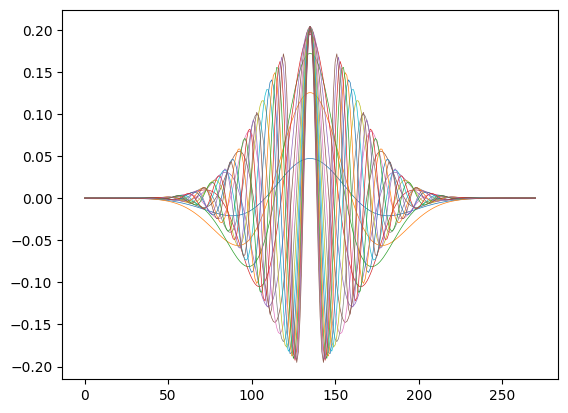

In [4]:
sfreq=32
n_freqs=16
freqs = np.linspace(0.5, 16, n_freqs)
n_cycles = freqs/1.5
wavelets = morlet(epochs.info['sfreq'],
                  freqs, n_cycles, zero_mean=True)
for i in range(n_freqs):
    plt.plot(np.real(wavelets[i]), linewidth=0.5)

In [5]:
epochs_tfr = tfr_morlet(epochs, freqs, n_cycles, return_itc=False, average=False,
                    output='power', verbose=True, n_jobs=-1, decim=int(epochs.info['sfreq']//sfreq))
epochs_tfr.crop(-0.5, 1)
epochs_tfr.apply_baseline((-0.5, -0.1), 'logratio')
epochs_tfr.apply_baseline((-0.5, -0.1), 'mean')
epochs_tfr.crop(0, 0.7)
epochs_tfr

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:   11.7s remaining:   19.6s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:   15.1s remaining:    9.0s


Not setting metadata


[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:   15.8s finished


Applying baseline correction (mode: logratio)
Applying baseline correction (mode: mean)


<EpochsTFR | time : [0.000000, 0.687500], freq : [0.500000, 16.000000], epochs : 4200, channels : 8, ~94.4 MB>

No baseline correction applied


/tmp/ipykernel_37221/2710777252.py:5: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


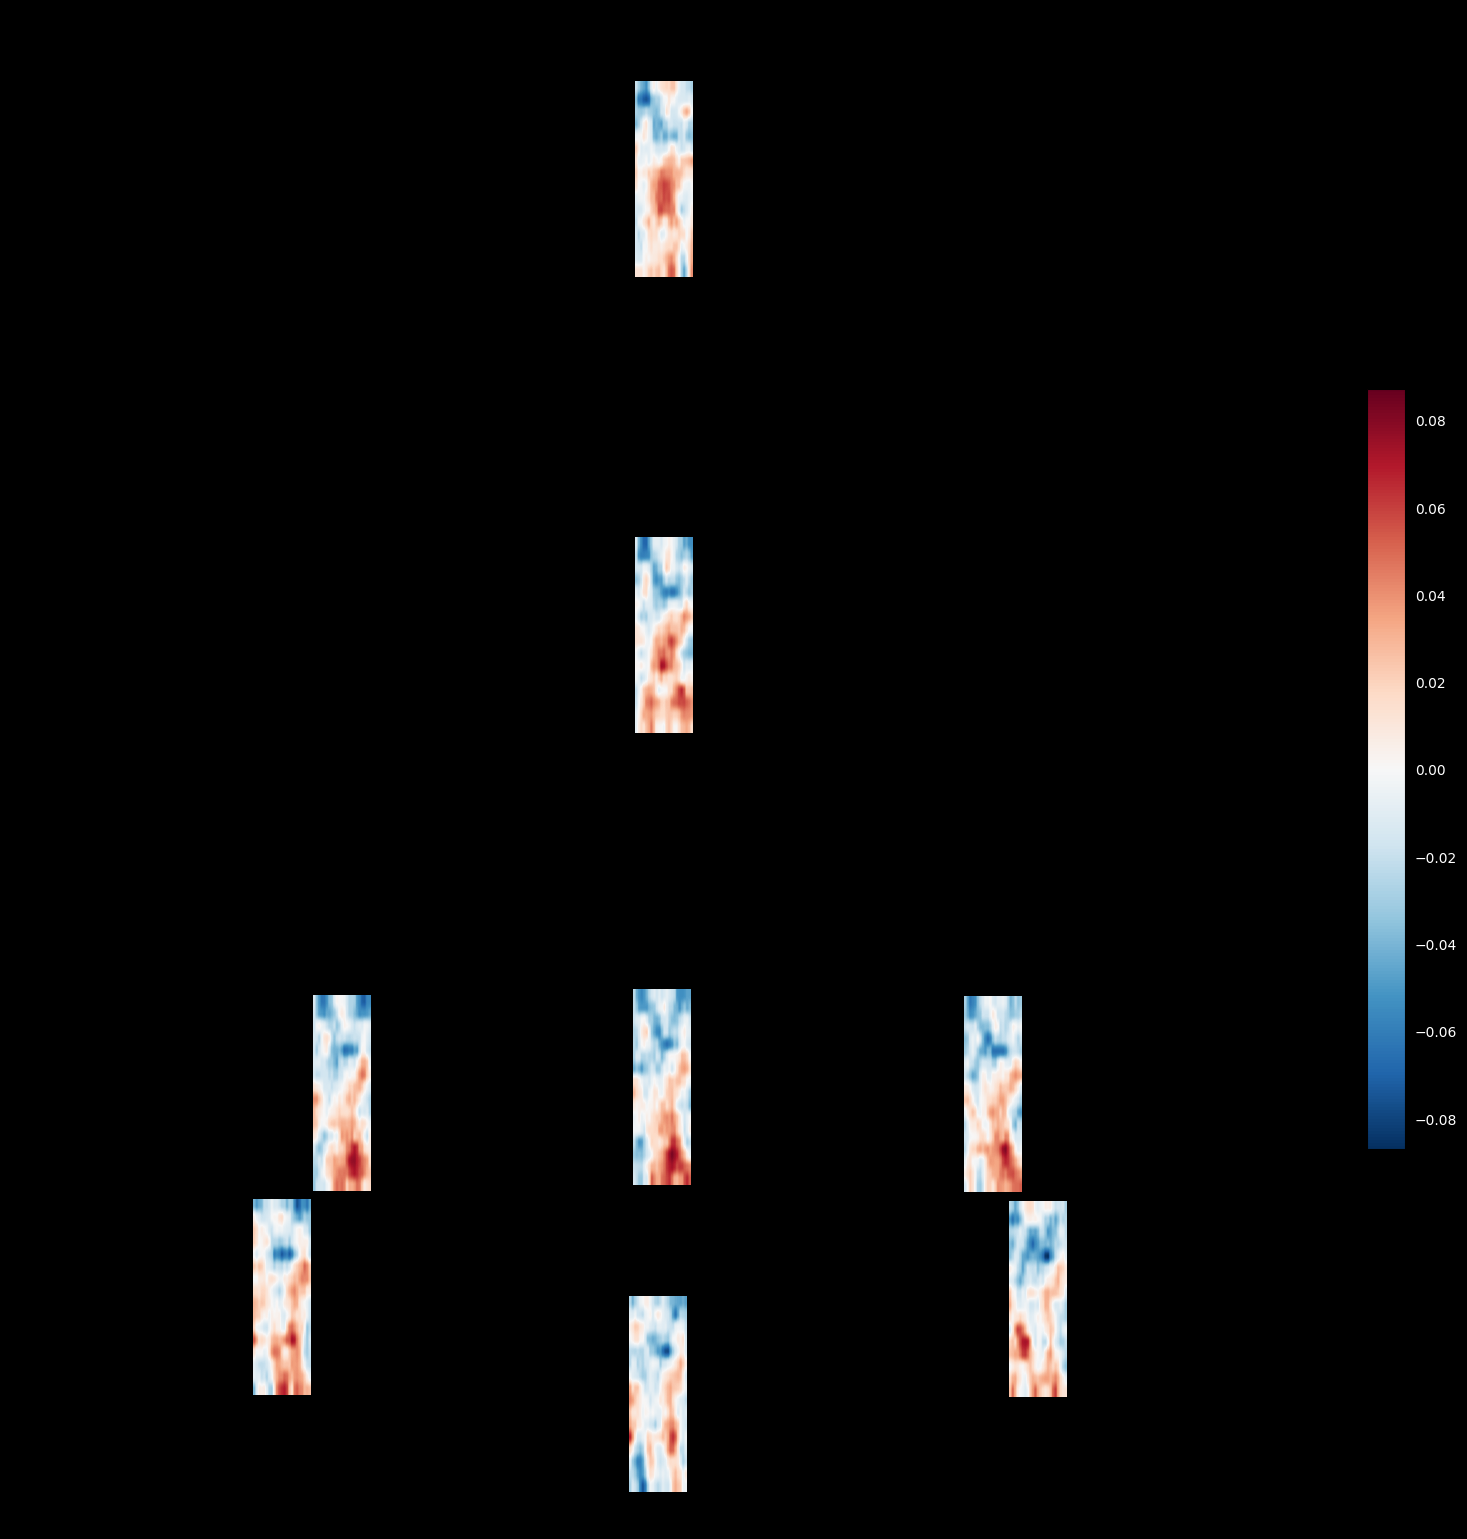

In [6]:
class_names = np.unique(labels)
avg_target = epochs_tfr['Target'].average()
fig = avg_target.plot_topo(show=False)
fig.set_size_inches(16, 16)
fig.show()

No baseline correction applied


/tmp/ipykernel_37221/476413951.py:4: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


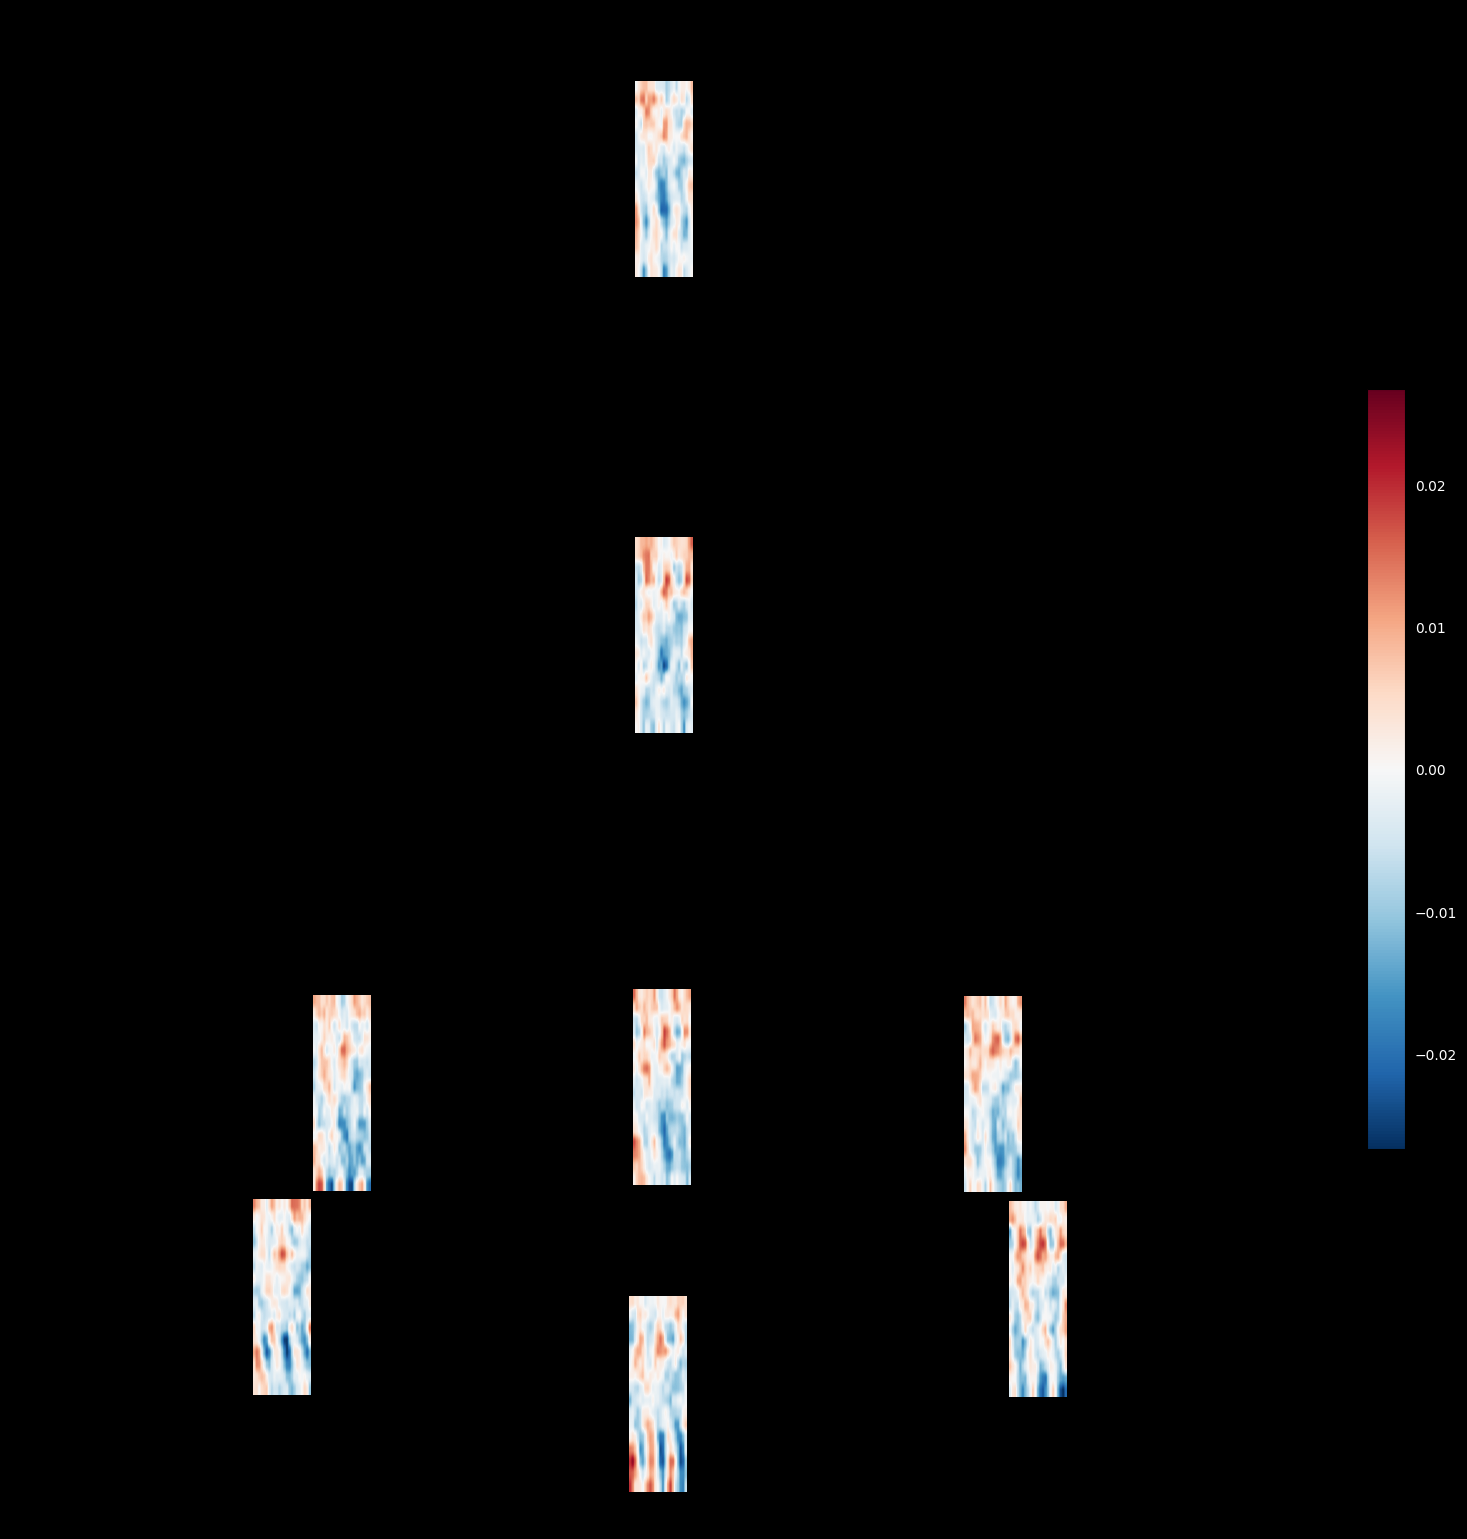

In [7]:
avg_non_target = epochs_tfr['NonTarget'].average()
fig = avg_non_target.plot_topo(show=False)
fig.set_size_inches(16, 16)
fig.show()

No baseline correction applied


/tmp/ipykernel_37221/3246555092.py:7: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


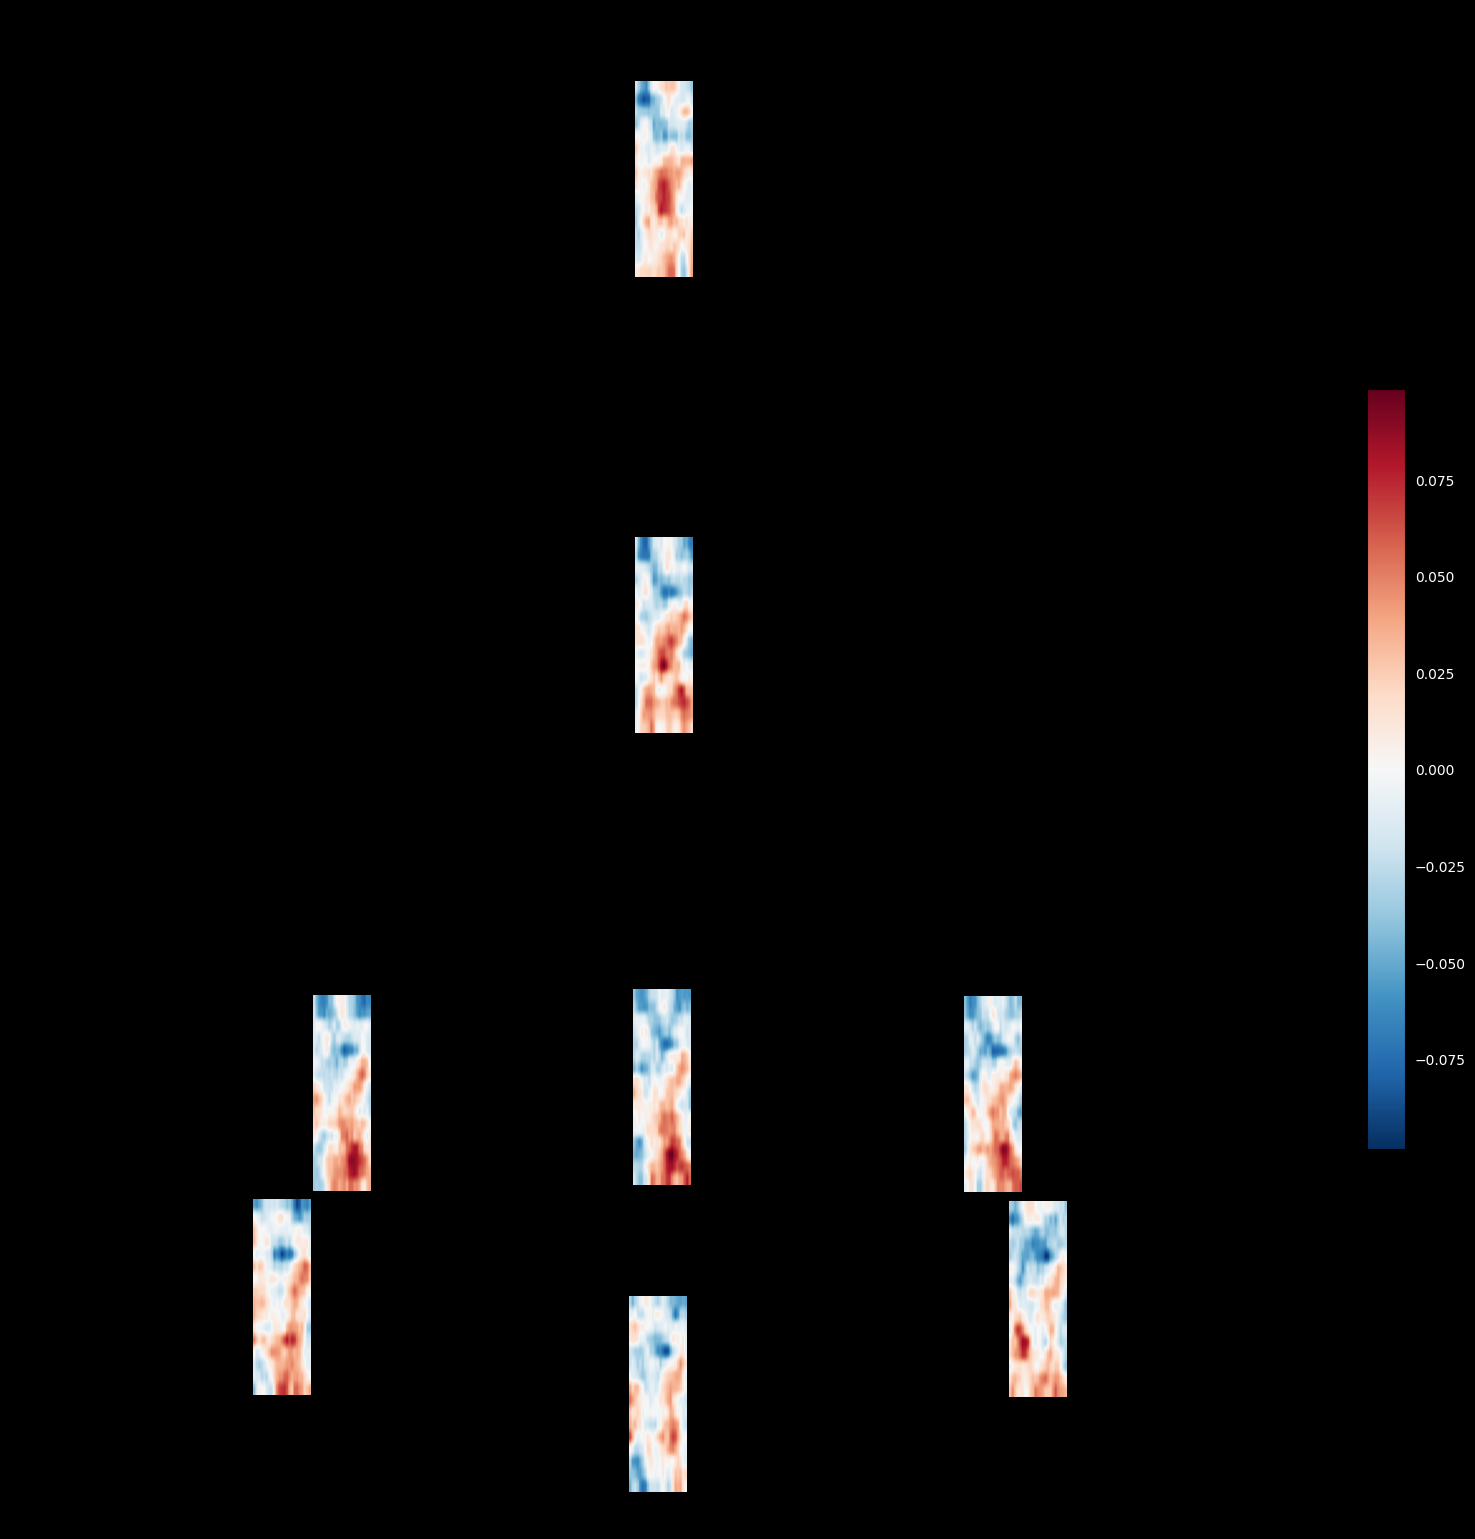

In [8]:
from mne import combine_evoked
from mne.viz import plot_tfr_topomap

contrast = combine_evoked([avg_target, avg_non_target], weights = [1,-1])
fig = contrast.plot_topo(show=False)
fig.set_size_inches(16, 16)
fig.show()

In [9]:
#epochs_data_flat = epochs.data.flatten()
#sns.jointplot(x=np.real(epochs_data_flat), y=np.imag(epochs_data_flat),kind="hex")

In [10]:
split = len(epochs)//2
epochs_train = epochs_tfr[:split]
epochs_test = epochs_tfr[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [11]:
X_train = epochs_train.data.astype(np.float32)
y_train = labels_train
X_test = epochs_test.data.astype(np.float32)
y_test = labels_test

In [12]:
X_train -= np.mean(X_train, axis=0)[np.newaxis,:,:,:]
X_train /= np.std(X_train, axis=0)[np.newaxis,:,:,:]
X_test -= np.mean(X_train, axis=0)[np.newaxis,:,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:,:]

In [13]:
import tensorly as tl
try:
    tl.set_backend('jax')
except AttributeError:
    tl.set_backend('jax')

In [40]:
hoda = HODA(max_iter=1024, rank=(8,8,8), tol=0, initialize ='identity', verbose=True,
            taper=None, shrinkage=(0.1,0.1,0.1), toeplitz=None)
hoda.fit(X_train,y_train)

[0/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=4.3250e+00  objective=0.0000e+00
[1/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=3.8013e+00  objective=0.0000e+00
[2/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=3.1574e+00  objective=0.0000e+00
[3/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=3.3025e+00  objective=0.0000e+00
[4/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=3.4790e+00  objective=0.0000e+00
[5/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=3.3283e+00  objective=0.0000e+00
[6/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=3.2169e+00  objective=0.0000e+00
[7/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=3.2341e+00  objective=0.0000e+00
[8/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=3.9493e+00  objective=0.0000e+00
[

[73/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=8.6210e-04  objective=0.0000e+00
[74/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=8.4512e-04  objective=0.0000e+00
[75/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=7.1412e-04  objective=0.0000e+00
[76/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=7.0009e-04  objective=0.0000e+00
[77/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=5.9159e-04  objective=0.0000e+00
[78/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=5.8000e-04  objective=0.0000e+00
[79/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=4.9012e-04  objective=0.0000e+00
[80/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=4.8054e-04  objective=0.0000e+00
[81/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=4.0609e-04  objective=0.0

[146/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=9.7614e-07  objective=0.0000e+00
[147/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=8.2498e-07  objective=0.0000e+00
[148/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=8.0900e-07  objective=0.0000e+00
[149/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=6.8372e-07  objective=0.0000e+00
[150/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=6.7048e-07  objective=0.0000e+00
[151/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=5.6665e-07  objective=0.0000e+00
[152/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=5.5567e-07  objective=0.0000e+00
[153/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=4.6963e-07  objective=0.0000e+00
[154/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=4.6053e-07  obje

[219/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=9.5529e-10  objective=0.0000e+00
[220/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=9.3679e-10  objective=0.0000e+00
[221/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=7.9175e-10  objective=0.0000e+00
[222/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=7.7638e-10  objective=0.0000e+00
[223/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=6.5616e-10  objective=0.0000e+00
[224/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=6.4348e-10  objective=0.0000e+00
[225/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=5.4382e-10  objective=0.0000e+00
[226/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=5.3328e-10  objective=0.0000e+00
[227/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=4.5070e-10  obje

[292/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=1.1250e-12  objective=0.0000e+00
[293/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=9.6773e-13  objective=0.0000e+00
[294/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=9.6019e-13  objective=0.0000e+00
[295/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=8.2017e-13  objective=0.0000e+00
[296/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=7.6408e-13  objective=0.0000e+00
[297/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=6.3995e-13  objective=0.0000e+00
[298/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=6.0310e-13  objective=0.0000e+00
[299/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=5.0711e-13  objective=0.0000e+00
[300/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=5.1346e-13  obje

...

[734/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=1.0578e-13  objective=0.0000e+00
[735/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=6.4393e-14  objective=0.0000e+00
[736/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=6.6789e-14  objective=0.0000e+00
[737/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=8.7010e-14  objective=0.0000e+00
[738/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=8.2733e-14  objective=0.0000e+00
[739/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=7.4478e-14  objective=0.0000e+00
[740/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=9.3053e-14  objective=0.0000e+00
[741/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=7.5475e-14  objective=0.0000e+00
[742/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=5.2644e-14  obje

[809/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=7.1797e-14  objective=0.0000e+00
[810/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=9.5530e-14  objective=0.0000e+00
[811/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=9.3671e-14  objective=0.0000e+00
[812/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=1.3567e-13  objective=0.0000e+00
[813/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=9.5638e-14  objective=0.0000e+00
[814/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=9.2566e-14  objective=0.0000e+00
[815/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=8.6970e-14  objective=0.0000e+00
[816/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=6.5361e-14  objective=0.0000e+00
[817/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=7.0398e-14  obje

[882/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=9.1943e-14  objective=0.0000e+00
[883/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=7.5539e-14  objective=0.0000e+00
[884/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=1.0273e-13  objective=0.0000e+00
[885/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=7.7515e-14  objective=0.0000e+00
[886/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=4.8619e-14  objective=0.0000e+00
[887/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=5.8544e-14  objective=0.0000e+00
[888/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=6.3662e-14  objective=0.0000e+00
[889/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=5.8691e-14  objective=0.0000e+00
[890/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=7.0707e-14  obje

[957/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=8.5281e-14  objective=0.0000e+00
[958/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=8.4730e-14  objective=0.0000e+00
[959/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=9.1906e-14  objective=0.0000e+00
[960/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=1.0649e-13  objective=0.0000e+00
[961/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=9.2916e-14  objective=0.0000e+00
[962/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=7.5024e-14  objective=0.0000e+00
[963/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=6.0896e-14  objective=0.0000e+00
[964/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=6.0427e-14  objective=0.0000e+00
[965/1024]  shrinkage[0]=0.1000  shrinkage[1]=0.1000  shrinkage[2]=0.1000  step=6.6469e-14  obje

HODA(max_iter=1024, rank=(8, 8, 8), shrinkage=(0.1, 0.1, 0.1), toeplitz=None,
     tol=0, verbose=True)

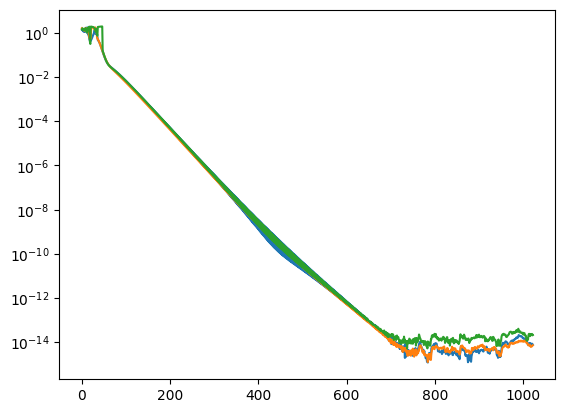

In [29]:
plt.semilogy(hoda.updates_[:,:hoda.iter_].T)
plt.show()

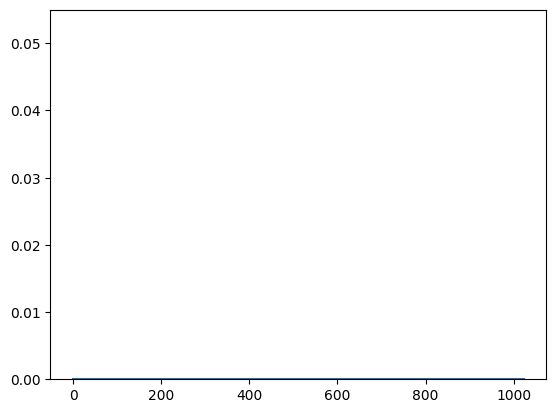

In [41]:
plt.plot(hoda.objective_)
plt.ylim([0,None])
plt.show()

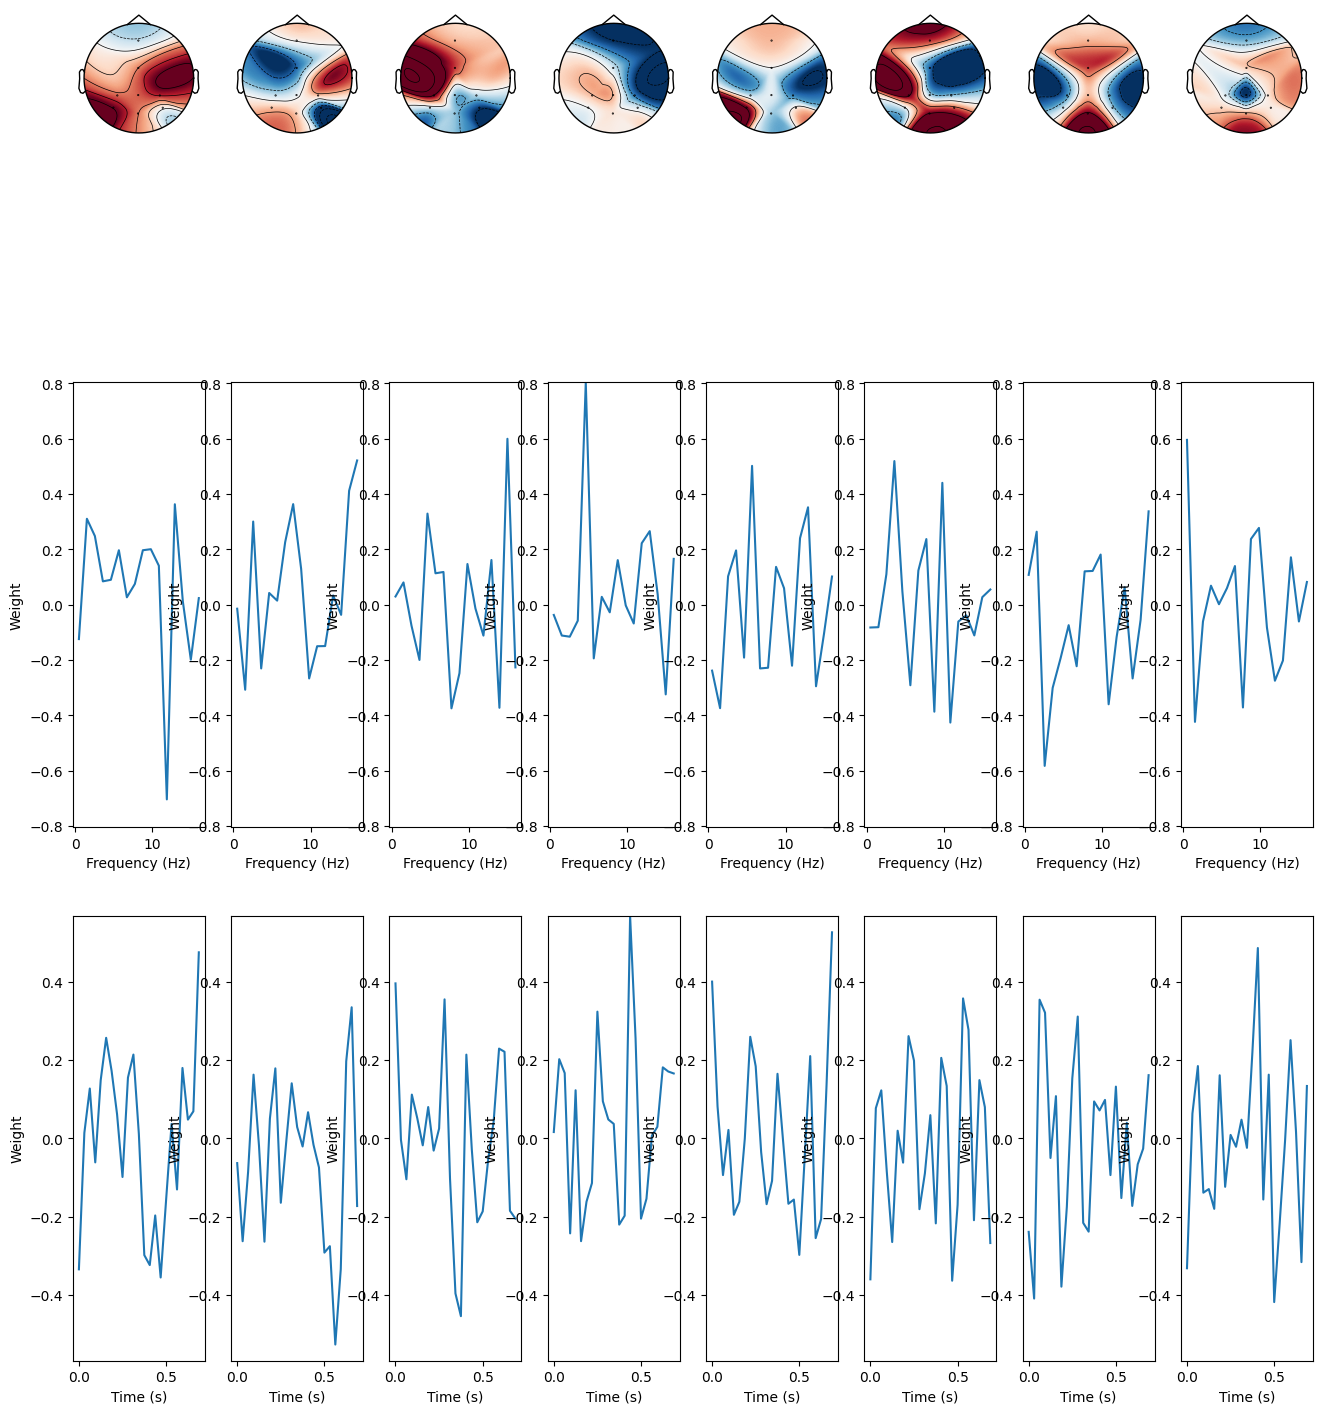

In [42]:
fig, axs = plt.subplots(3,max(hoda.rank), figsize=(16,6*3))
sp_rank = min(hoda.rank[0], len(epochs.ch_names))
for i in range(sp_rank):
    w = hoda.projs_[0][:,i]
    if sp_rank >1:
        plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(hoda.projs_[1]))
for i in range(hoda.rank[1]):
    w = hoda.projs_[1][:,i]
    axs[1,i].plot(freqs, w)
    axs[1,i].set_xlabel('Frequency (Hz)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])
vmax = np.max(np.abs(hoda.projs_[2]))
for i in range(hoda.rank[2]):
    w = hoda.projs_[2][:,i]
    axs[2,i].plot(epochs_tfr.times, w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Weight')
    axs[2,i].set_ylim([-vmax, vmax])

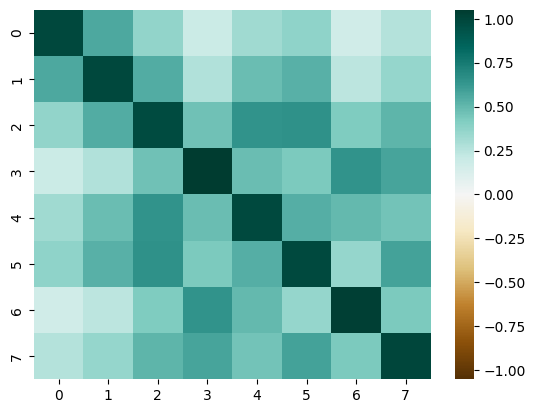

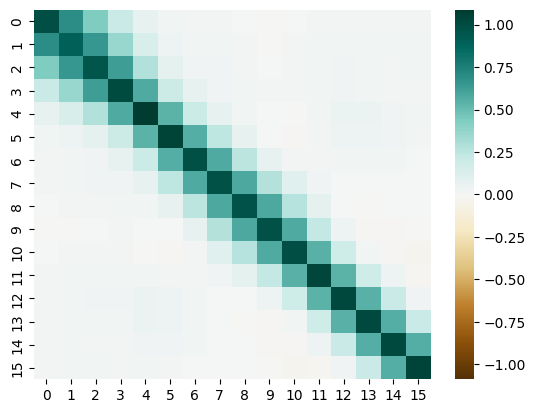

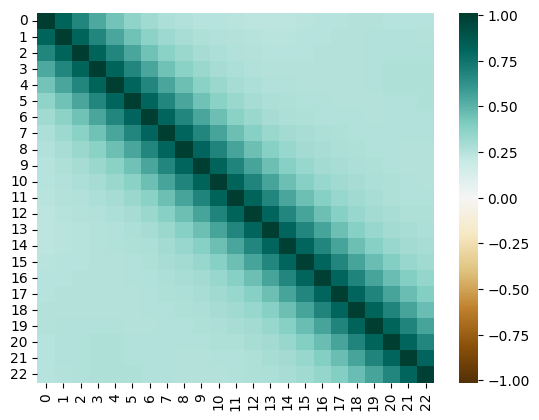

In [43]:
for k in range(3):
    cov = hoda.scatter_w_[k]
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

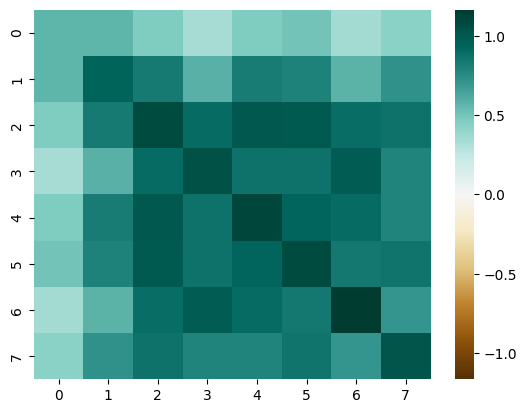

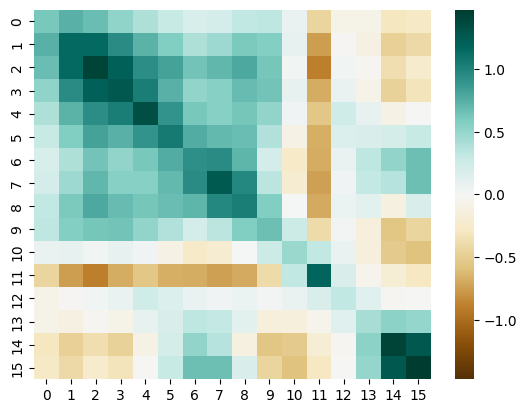

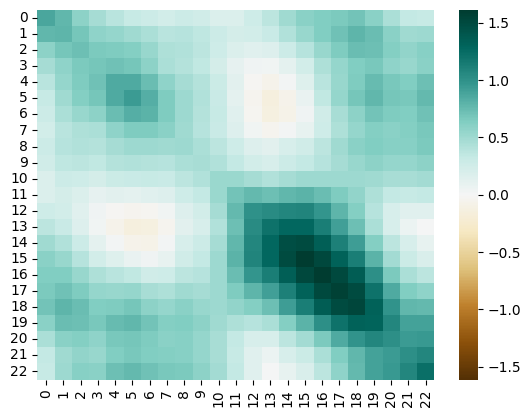

In [44]:
for k in range(3):
    cov = hoda.scatter_b_[k]
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

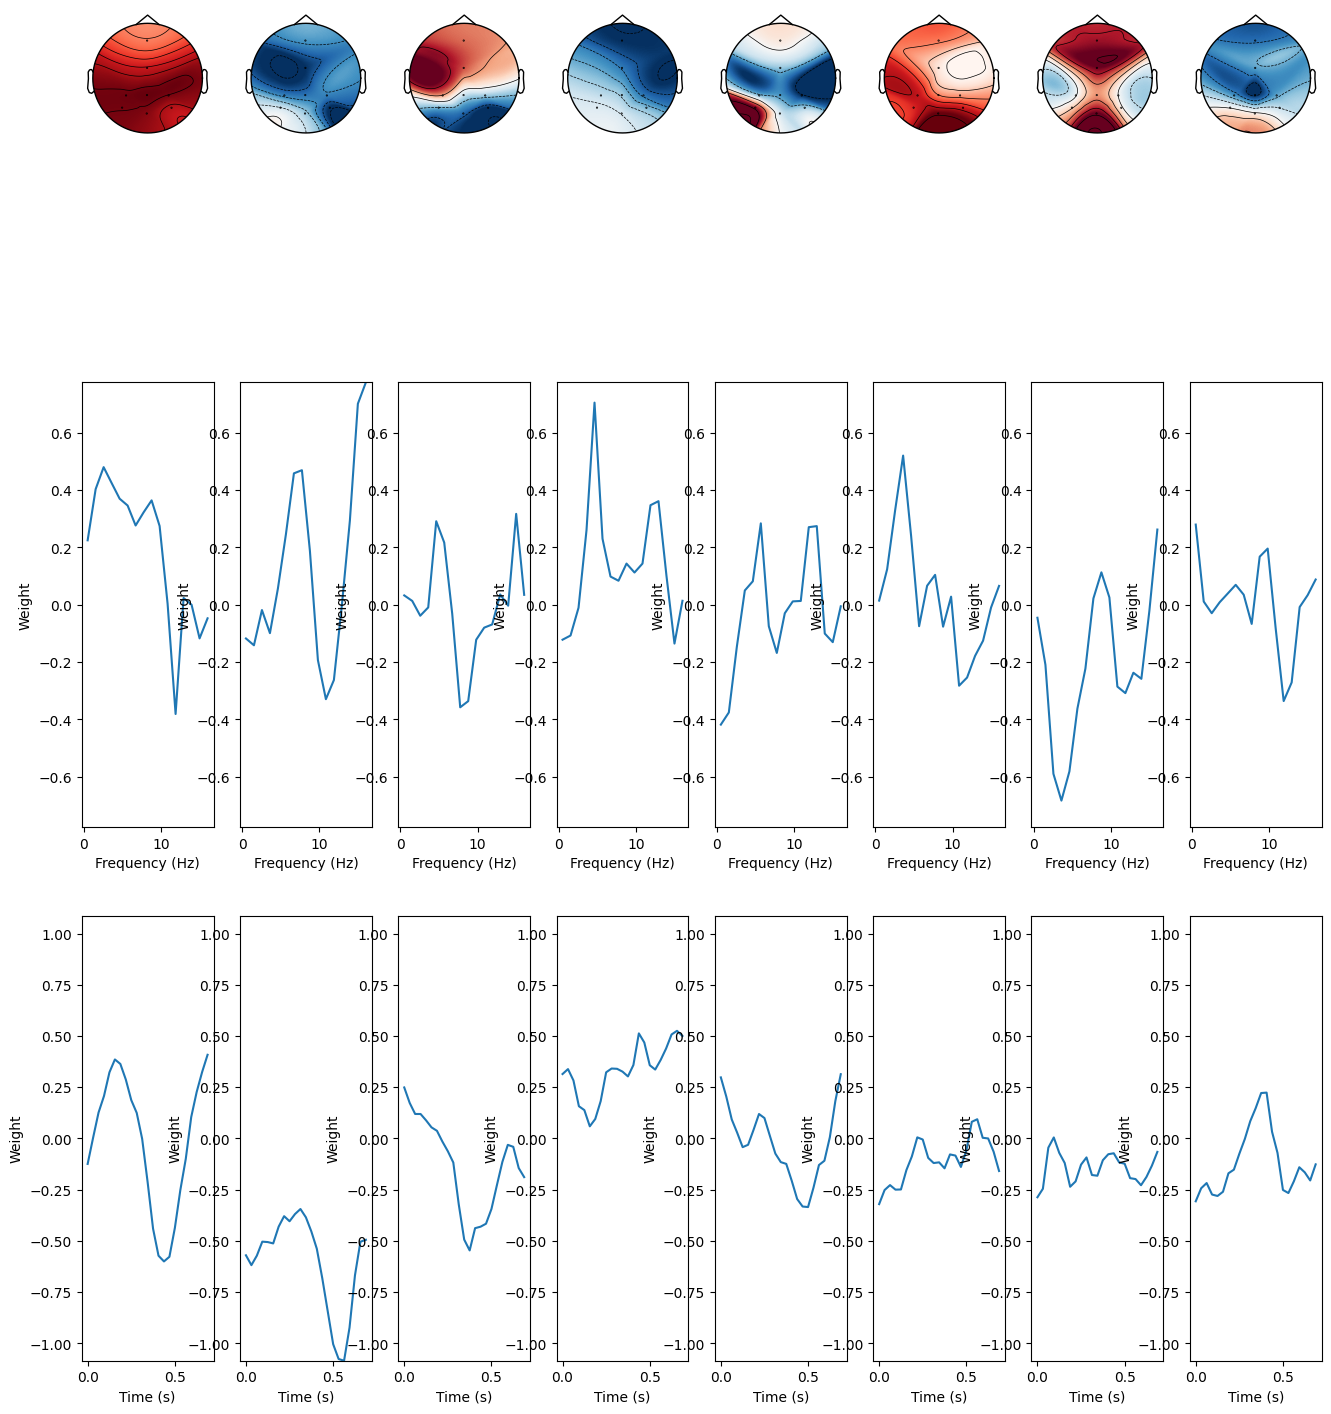

In [45]:
fig, axs = plt.subplots(3,max(hoda.rank), figsize=(16,6*3))
aps = [hoda.scatter_w_[k] @ p for k,p in enumerate(hoda.projs_)]
for i in range(sp_rank):
    w = aps[0][:,i]
    if sp_rank > 1:
        plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(aps[1]))
for i in range(hoda.rank[1]):
    w = aps[1][:,i]
    axs[1,i].plot(freqs, w)
    axs[1,i].set_xlabel('Frequency (Hz)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])
vmax = np.max(np.abs(aps[2]))
for i in range(hoda.rank[2]):
    w = aps[2][:,i]
    axs[2,i].plot(epochs_tfr.times, w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Weight')
    axs[2,i].set_ylim([-vmax, vmax])

In [46]:
Xt_train = hoda.transform(tl.tensor(X_train))
Xt_test = hoda.transform(tl.tensor(X_test))

In [47]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(penalty='l1', solver='liblinear')
classifier.fit(Xt_train,y_train)

LogisticRegression(penalty='l1', solver='liblinear')

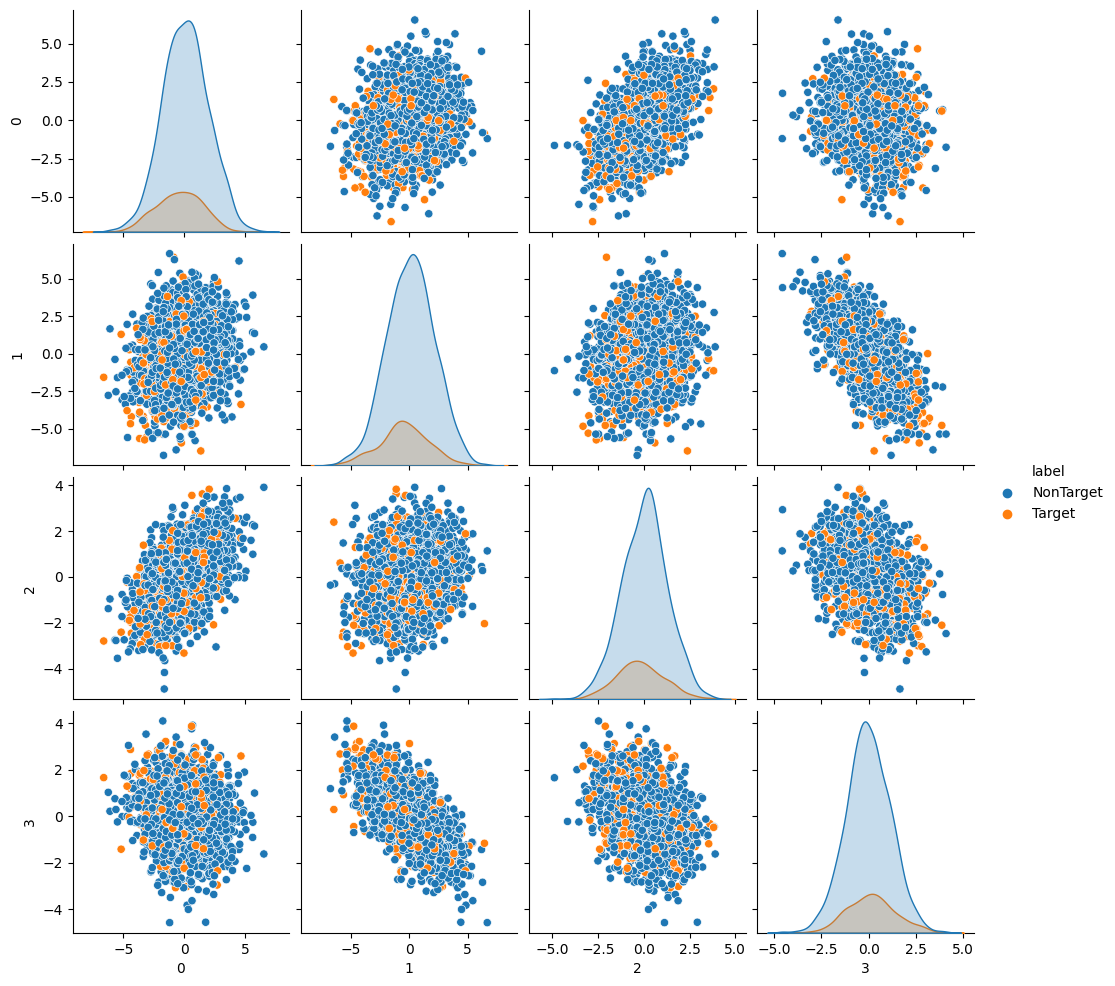

In [48]:
import seaborn as sns
import pandas as pd
Xt_train = hoda.transform(tl.tensor(X_train))
n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train[:,:4])
df_train['label'] = y_train
sns.pairplot(df_train, hue='label')

In [49]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.9469942857142857

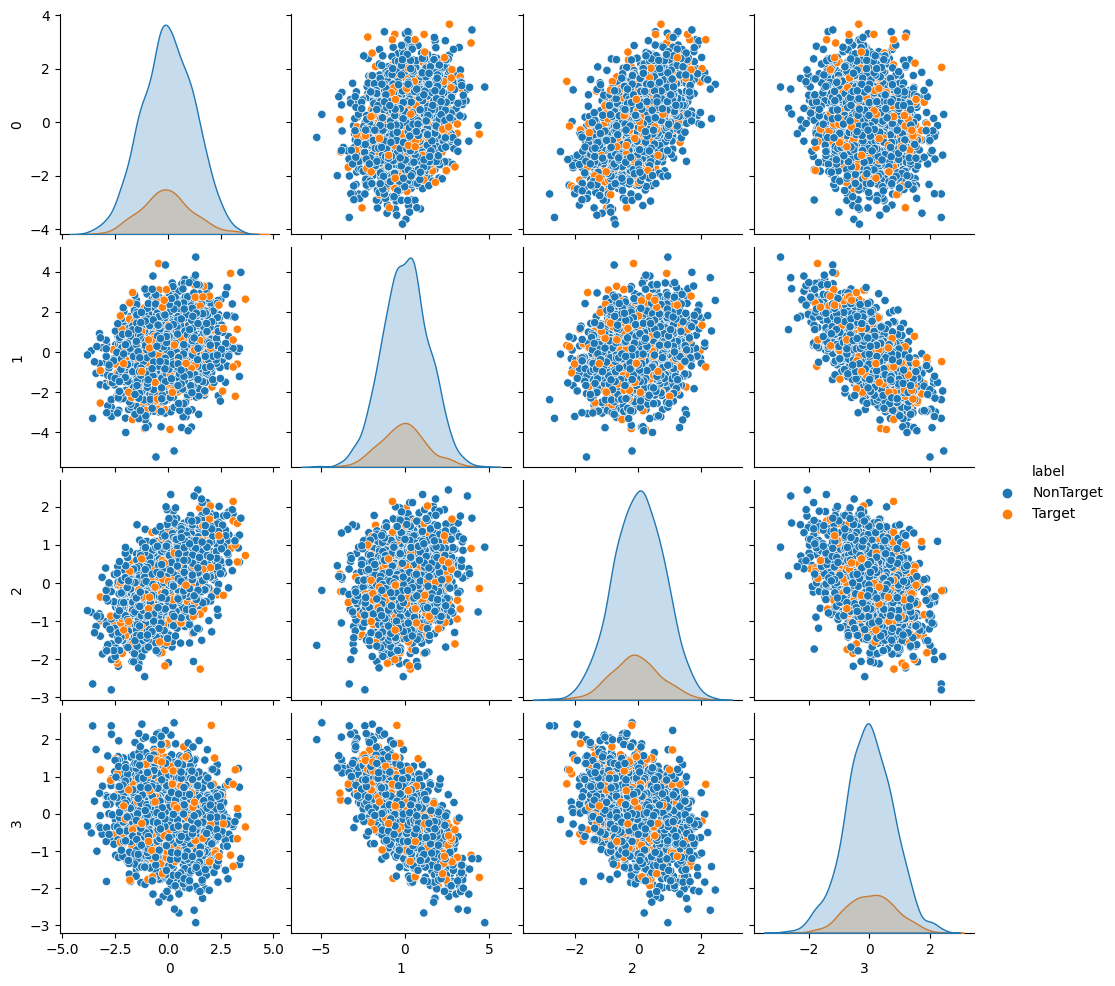

In [50]:
Xt_test = hoda.transform(tl.tensor(X_test))
df_test = pd.DataFrame(Xt_test[:,:4])
df_test['label'] = y_test
sns.pairplot(df_test, hue='label')

In [51]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.5260555102040816